# **Step 1 – Load & Inspect Data**


In [1]:
from google.colab import files
uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles.csv


In [3]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [4]:
#Load Dataset and Display first few rows
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [8]:
df.shape


(8807, 12)

In [9]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [10]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


1)The dataset contains information about Netflix movies and TV shows.
2)It has approximately 8,800 records and 12 columns.
3)The dataset includes title, director, cast, country, release year, rating, duration, and genre.
4)Some columns contain missing values, especially director and cast.
5)The dataset can be used to analyze Netflix content trends and distributions.

# **Step 2 — Clean the Data**

In [11]:
df.duplicated().sum()

np.int64(0)

In [13]:
#Remove Duplicates
df = df.drop_duplicates()

In [14]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [16]:
df["director"] = df["director"].fillna("Unknown")

In [17]:
df["cast"] = df["cast"].fillna("Unknown")

In [19]:
df["country"] = df["country"].fillna("Unknown")

In [21]:
df = df.dropna(subset=["date_added"])

In [30]:
df["date_added"].dtype
df["year_added"] = df["date_added"].dt.year
df["year_added"].head()

,year_added
0,2021
1,2021
2,2021
3,2021
4,2021


In [31]:
df["month_added"] = df["date_added"].dt.month_name()
df["year_added"].value_counts().sort_index()

,count
year_added,
2008,2
2009,2
2010,1
2011,13
2012,3
2013,11
2014,24
2015,82
2016,429


## **Step 3: Exploratory Data Analysis**

#Question 1: How many Movies and TV Shows are there?

In [32]:
df["type"].value_counts()

,count
type,
Movie,6131
TV Show,2666


Netflix has 6131 movies and 2666 TV Show


# Question 2: Which countries have the most Netflix titles?

In [33]:
df["country"].value_counts().head(10)

,count
country,
United States,2812
India,972
Unknown,830
United Kingdom,418
Japan,244
South Korea,199
Canada,181
Spain,145
France,124


# United States has most netflix titles

# Question 3: What are the most common content ratings?

In [34]:
df["rating"].value_counts()

,count
rating,
TV-MA,3205
TV-14,2157
TV-PG,861
R,799
PG-13,490
TV-Y7,333
TV-Y,306
PG,287
TV-G,220


# TV-MA (Mature Audience) is the most common rating.

# Question 4: How many titles were released each year?

In [37]:
titles_per_year = df.groupby("release_year")["title"].count()
titles_per_year

,title
release_year,
1925,1
1942,2
1943,3
1944,3
1945,4
...,...
2017,1032
2018,1146
2019,1030


# I have  notice that:

# Older years have fewer titles.
# Recent years have many more releases.

# Question 5: Which genres are most common?

In [38]:
df["listed_in"].value_counts().head(10)

,count
listed_in,
"Dramas, International Movies",362
Documentaries,359
Stand-Up Comedy,334
"Comedies, Dramas, International Movies",274
"Dramas, Independent Movies, International Movies",252
Kids' TV,219
Children & Family Movies,215
"Children & Family Movies, Comedies",201
"Documentaries, International Movies",186


# Drama and International Movies appear frequently.
# Documentaries are also popular.

# Conclusion
1.Netflix has significantly more Movies than TV Shows.
2.The United States is the leading producer of Netflix content, followed by India.
3.Most Netflix content is intended for mature audiences, as TV-MA is the most common rating.
4.The number of titles released increased rapidly in recent years.
5.Drama and International Movies are among the most common genres on Netflix.

# **Step 4: Data Visualization**

# 1. Bar Chart
# Question:

# How many Movies and TV Shows are available on Netflix?

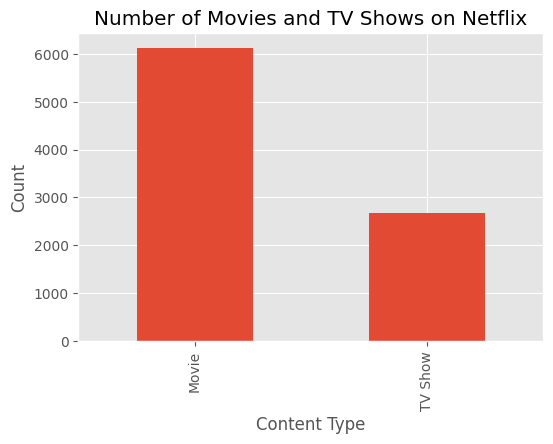

In [39]:
type_counts = df["type"].value_counts()

plt.figure(figsize=(6,4))
type_counts.plot(kind="bar")

plt.title("Number of Movies and TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.show()

# 2. Line Chart
# Question:

# How has the number of titles released changed over the years?

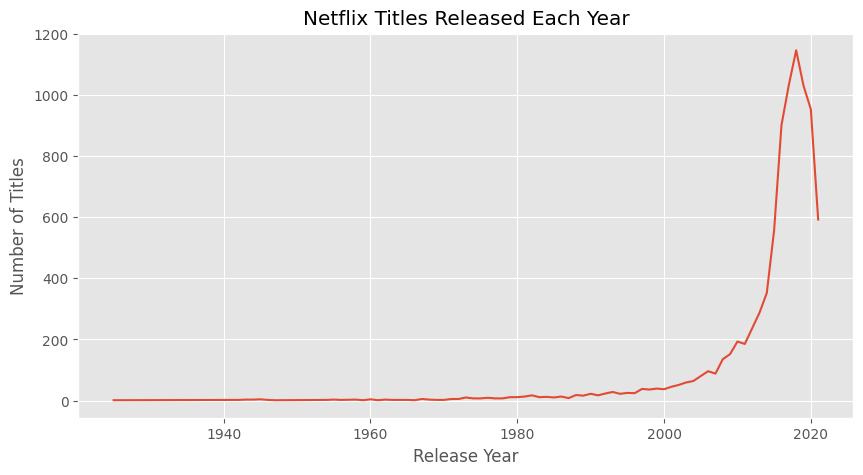

In [40]:
titles_per_year = df.groupby("release_year")["title"].count()

plt.figure(figsize=(10,5))
titles_per_year.plot()

plt.title("Netflix Titles Released Each Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

# 3. Histogram
# Question:

# How are release years distributed?

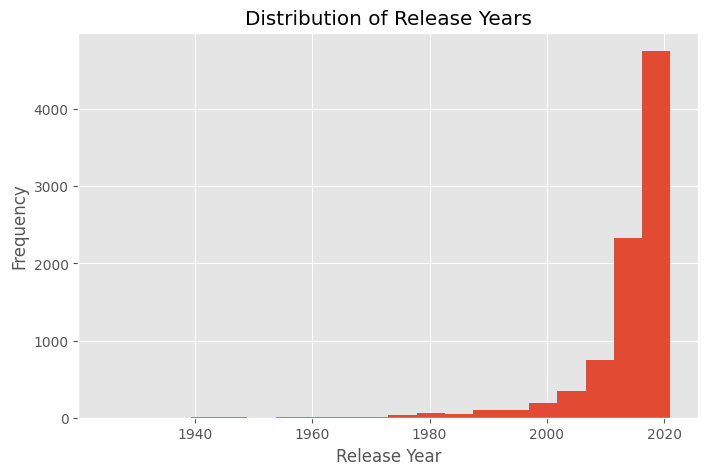

In [41]:
plt.figure(figsize=(8,5))

plt.hist(df["release_year"], bins=20)

plt.title("Distribution of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Frequency")

plt.show()

# 4. Scatter Plot
# Question:

# How are release years spread across the dataset?

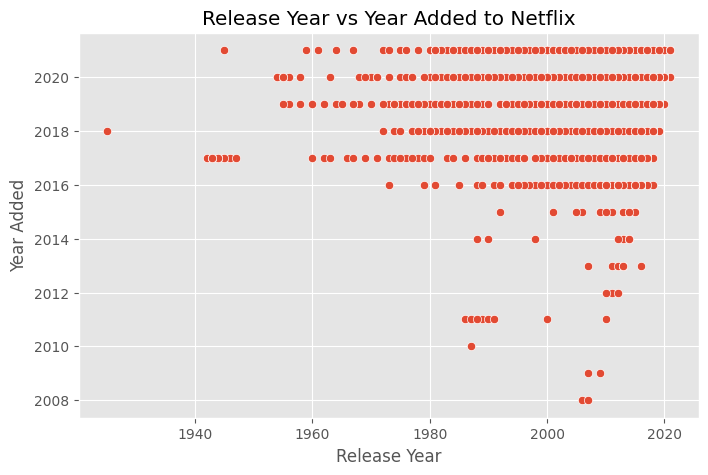

In [42]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="release_year",
    y="year_added"
)

plt.title("Release Year vs Year Added to Netflix")
plt.xlabel("Release Year")
plt.ylabel("Year Added")

plt.show()

# 5. Pie Chart
# Question:

# What percentage of Netflix content is Movies vs TV Shows?

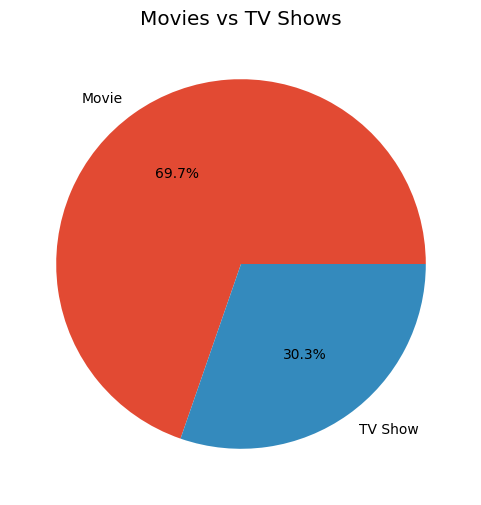

In [43]:
plt.figure(figsize=(6,6))

df["type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Movies vs TV Shows")
plt.ylabel("")

plt.show()

# 6. Heatmap

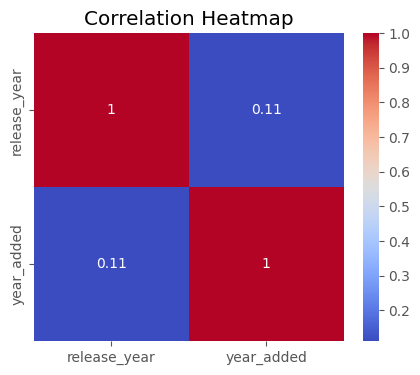

In [47]:
numeric_df = df[["release_year", "year_added"]]

plt.figure(figsize=(5,4))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# **Step 5: Insights Report**

# Insight 1

The bar chart showed that Netflix has significantly more Movies than TV Shows. This indicates that movies make up the majority of Netflix's content library.

# Insight 2

The country analysis revealed that the United States contributes the highest number of titles on Netflix, followed by countries such as India. This shows that Netflix has a strong presence in these regions.

# Insight 3

The line chart showed that the number of titles released increased rapidly in recent years, indicating significant growth in Netflix's content collection.

# Insight 4

The histogram showed that most Netflix titles were released after 2010, suggesting that the platform mainly focuses on modern content.

# Insight 5

The pie chart confirmed that Movies occupy a much larger share of the Netflix catalog than TV Shows, showing Netflix's stronger emphasis on movies.


# **Which finding surprised you the most?**
The most surprising finding was that Netflix has far more Movies than TV Shows. I also observed that most content was released after 2010, showing how quickly Netflix's library has grown. Another interesting finding was that the United States contributes the largest number of titles available on the platform.

